In [ ]:
import os
import json
import matplotlib.pylab as plt
import numpy as np
from pathlib import Path
import random
from tyssue.draw.plt_draw import draw_edge, draw_vert
import traceback



from scipy.optimize import curve_fit
from matplotlib.colors import ListedColormap


# Importing my modules

repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

import src.vertexModel1 as vertexModel1
import src.vertexModel2 as vertexModel2

import src.inputMechanicalParametersModel1 as MechanicalParams1
import src.inputMechanicalParametersModel2 as MechanicalParams2


import src.auxFunctions as auxFunctions



import warnings
warnings.filterwarnings("ignore")


### Model 1 collagenase laser ablations

In [ ]:
# HELPER FUNCTIONS

# Registering a custom colormap
if 'yellow_red' not in plt.colormaps():
    custom_cmap = ListedColormap(["yellow", "red"])
    plt.register_cmap(name='yellow_red', cmap=custom_cmap)

def highlight_edge_on_cellmap(cellmap_init, edge_id=None, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='lightgray', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True):
    """
    Plots a Tyssue cellmap with the ablated edge highlighted in red.
    """

    cellmap = cellmap_init.copy()
    coords = cellmap.coords[:2]  # 2D coordinates

    fig, ax = plt.subplots(figsize=figsize)

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Drawing all edges in light gray first (background)
    draw_edge(
        cellmap,
        coords=coords,
        ax=ax,
        color=base_edge_col,
        width=2,
        head_width=0.0,
        alpha=0.5,
        zorder=1
    )

    # If an edge is specified, drawing it in red on top
    if edge_id is not None and edge_id in cellmap.edge_df.index:
        ax.plot(
            [cellmap.vert_df.loc[cellmap.edge_df.loc[edge_id, 'srce'], 'x'],
             cellmap.vert_df.loc[cellmap.edge_df.loc[edge_id, 'trgt'], 'x']],
            [cellmap.vert_df.loc[cellmap.edge_df.loc[edge_id, 'srce'], 'y'],
             cellmap.vert_df.loc[cellmap.edge_df.loc[edge_id, 'trgt'], 'y']],
            color=edge_highlight_col,
            linewidth=4,
            zorder=3,
            label='Ablated Edge'
        )
    elif edge_id is not None:
        print(f"Warning: Edge ID {edge_id} not found in edge_df")

    # Outlining all edges with a thin black line
    draw_edge(
        cellmap,
        coords=coords,
        ax=ax,
        color='black',
        width=1,
        head_width=0.0,
        alpha=0.7,
        zorder=2
    )

    # Drawing vertices
    if plot_vertices:
        draw_vert(
            cellmap,
            coords=coords,
            ax=ax,
            color=base_vert_col,
            s=vert_size,
            alpha=1.0,
            zorder=4
        )
        draw_vert(
            cellmap,
            coords=coords,
            ax=ax,
            color=vert_col,
            s=vert_size - 30,
            alpha=1.0,  
            zorder=5
        )

    if show_axes:
        ax.set_xlabel("X", fontsize=14)
        ax.set_ylabel("Y", fontsize=14)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_aspect('equal')
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    if edge_id is not None:
        ax.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    if show_figure:
        plt.show()
    elif not show_figure and save_path is None:
        plt.close(fig)
    
    return fig, ax


### Function to plot laser ablation recoil curve

def plot_recoil_curve(time_steps, displacement, initial_recoil, k, tissue_id, ablation_id):
    """
    Plot and display the recoil displacement curve with fitted model.
    """
    print(f"Displaying recoil curve for tissue {tissue_id}, ablation {ablation_id}...")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot actual displacement
    ax.plot(time_steps, displacement, 'b-', linewidth=2, label='Actual displacement')
    
    # Plot fitted model
    fitted_displacement = (initial_recoil / k) * (1 - np.exp(-k * np.array(time_steps)))
    ax.plot(time_steps, fitted_displacement, 'r--', linewidth=2, label=f'Fit: K={k:.3f}, v0={initial_recoil:.5f}')
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Displacement', fontsize=12)
    ax.set_title(f'Model 2 Recoil Dynamics - Tissue {tissue_id}, Ablation {ablation_id}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()
    print(f"Recoil curve displayed")

def set_ecm_frc_ratio(cellmap, ecm_ratio, frc_ratio, total_le=90, remove_ecm=False):
    """
    Partition length elasticity between ECM and FRC.
    """
    frc_to_ecm_ratio = frc_ratio / ecm_ratio
    frc_le = (frc_to_ecm_ratio / (1 + frc_to_ecm_ratio)) * total_le
    ecm_le = total_le - frc_le
    
    if remove_ecm:
        ecm_le = 0
    
    cellmap.edge_df['length_elasticity_ECM'] = ecm_le
    cellmap.edge_df['length_elasticity_FRC'] = frc_le
    cellmap.edge_df['length_elasticity'] = frc_le + ecm_le
    
    return cellmap


def initialize_tissue_with_ratio(ratio_ecm_frc, remove_ecm=False, total_le=90):
    """
    Initialize tissue with specified ECM:FRC ratio.
    """
    cellmap, geom, energy_model = vertexModel1.initialize()
    cellmap = MechanicalParams1.update(cellmap)
    
    # Fix outer boundary vertices
    boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, 1)
    for vertex_id in outside_vertices:
        if vertex_id in cellmap.vert_df.index:
            cellmap.vert_df.at[vertex_id, "viscosity"] = 200000
    
    cellmap.update_specs({"vert": {"viscosity": cellmap.vert_df["viscosity"].values}}, reset=True)
    
    ecm_ratio, frc_ratio = ratio_ecm_frc
    cellmap = set_ecm_frc_ratio(cellmap, ecm_ratio, frc_ratio, total_le, remove_ecm)
    
    energy_model.compute_energy(cellmap)
    cellmap, geom, energy_model, _, _ = vertexModel1.solveEuler(
        cellmap, geom, energy_model, endTime=100
    )
    
    return cellmap, geom, energy_model


def perform_laser_ablation(cellmap, geom, energy_model, endTime=50, ratio_name=None, ablation_id=None, plot_dir=None):
    """
    Perform laser ablation on a random interior edge with visualization.
    RETURNS the updated cellmap after ablation.
    """
    # Finding interior edges
    boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, max_layers=1)
    if not inside_edges:
        raise ValueError("No inside edges found")
    
    # Choosing random edge and finding its opposite edge
    chosen_edge = random.choice(inside_edges)
    srce = cellmap.edge_df.loc[chosen_edge, "srce"]
    trgt = cellmap.edge_df.loc[chosen_edge, "trgt"]
    
    opposite = cellmap.edge_df[
        (cellmap.edge_df["srce"] == trgt) & (cellmap.edge_df["trgt"] == srce)
    ]
    if opposite.empty:
        raise ValueError("Opposite edge not found")
    opposite_edge = opposite.index[0]
    
    # Visualising edge choice before ablation
    if plot_dir and ratio_name and ablation_id is not None:
        print(f"Tissue before ablation")
        highlight_edge_on_cellmap(
            cellmap, 
            edge_id=chosen_edge,
            figsize=(12, 12),
            vert_col='orange',
            edge_highlight_col='red',
            save_path=f"{plot_dir}/before_ablation_{ratio_name.replace(':', '_')}_abl{ablation_id}.png",
            show_figure=False
        )
    
    # Ablating chosen edge
    cellmap.edge_df.at[chosen_edge, "length_elasticity"] = 0.0
    cellmap.edge_df.at[chosen_edge, "line_tension"] = 0.0
    cellmap.edge_df.at[opposite_edge, "length_elasticity"] = 0.0
    cellmap.edge_df.at[opposite_edge, "line_tension"] = 0.0
    
    # Relaxing the model
    energy_model.compute_energy(cellmap)
    cellmap, geom, energy_model, _, solver = vertexModel1.solveEuler(
        cellmap, geom, energy_model, endTime=endTime
    )
    
    # Visualising after ablation
    if plot_dir and ratio_name and ablation_id is not None:
        print(f"Tissue after ablation")
        highlight_edge_on_cellmap(
            cellmap, 
            edge_id=chosen_edge,
            figsize=(12, 12),
            vert_col='orange',
            edge_highlight_col='red',
            save_path=f"{plot_dir}/after_ablation_{ratio_name.replace(':', '_')}_abl{ablation_id}.png",
            show_figure=False
        )
    
    # Tracking vertex displacement post ablation
    displacement = []
    time_steps = []
    initial_distance = None
    
    for t, cm in solver.history:
        srce_coords = cm.vert_df.loc[srce, ['x', 'y']]
        trgt_coords = cm.vert_df.loc[trgt, ['x', 'y']]
        distance = np.linalg.norm(srce_coords - trgt_coords)
        
        if initial_distance is None:
            initial_distance = distance
        
        displacement.append(distance - initial_distance)
        time_steps.append(t)
    
    # Fitting exponential recoil model
    def recoil_model(t, initial_recoil, k):
        return (initial_recoil / k) * (1 - np.exp(-k * t))
    
    params, _ = curve_fit(recoil_model, time_steps, displacement, 
                          p0=[0.00001, 3], bounds=(0, np.inf))
    initial_recoil, k = params
    
    # Plotting recoil
    if plot_dir and ratio_name and ablation_id is not None:
        plot_recoil_curve(
            time_steps, displacement, initial_recoil, k, 
            ratio_name, ablation_id
        )
    
    return {
        'displacement': displacement,
        'time_steps': time_steps,
        'initial_recoil': float(initial_recoil),
        'k': float(k),
        'chosen_edge': int(chosen_edge),
        'opposite_edge': int(opposite_edge),
        'updated_cellmap': cellmap,  # Return the updated cellmap
        'updated_geom': geom,
        'updated_energy_model': energy_model
    }


# MAIN EXPERIMENT FUNCTIONS

def run_collagenase_experiment(ratio_ecm_frc, 
                                num_tissues=3, 
                                ablations_per_tissue=5,
                                total_le=90,
                                save_path=None,
                                plot_dir=None):
    """
    Running collagenase experiment for a single ECM:FRC ratio with plotting.
    Performs consecutive ablations on the same tissue.
    """
    ecm_ratio, frc_ratio = ratio_ecm_frc
    ratio_name = f"{ecm_ratio}:{frc_ratio}"
    
    print(f"\n{'='*60}")
    print(f"Testing ratio {ratio_name} (ECM:FRC)")
    print(f"Collagenase: ECM will be removed after initial relaxation")
    print(f"{'='*60}")
    
    # Creating plot directory for chosen ratio
    if plot_dir:
        ratio_plot_dir = f"{plot_dir}/ratio_{ecm_ratio}_{frc_ratio}"
        Path(ratio_plot_dir).mkdir(parents=True, exist_ok=True)
    else:
        ratio_plot_dir = None
    
    results = {
        'ratio': ratio_name,
        'ecm_ratio': ecm_ratio,
        'frc_ratio': frc_ratio,
        'total_le': total_le,
        'ablations': []
    }
    
    for tissue_idx in range(num_tissues):
        print(f"\n--- Tissue {tissue_idx + 1}/{num_tissues} ---")
        
        # Initializing with ECM present
        print("  Initializing tissue with ECM present...")
        cellmap, geom, energy_model = initialize_tissue_with_ratio(
            ratio_ecm_frc, remove_ecm=False, total_le=total_le
        )
        
        # Applying collagenase (removing ECM)
        print("  Applying collagenase (removing ECM)...")
        cellmap = set_ecm_frc_ratio(cellmap, ecm_ratio, frc_ratio, 
                                     total_le=total_le, remove_ecm=True)
        
        # Relaxing after collagenase
        energy_model.compute_energy(cellmap)
        cellmap, geom, energy_model, _, _ = vertexModel1.solveEuler(
            cellmap, geom, energy_model, endTime=100
        )
        
        # Record LE values after collagenase (before any ablations)
        frc_le_value = float(cellmap.edge_df['length_elasticity_FRC'].iloc[0])
        ecm_le_value = float(cellmap.edge_df['length_elasticity_ECM'].iloc[0])
        
        # Performing consecutive laser ablations on the same tissue
        for ablation_idx in range(ablations_per_tissue):
            ablation_num = tissue_idx * ablations_per_tissue + ablation_idx + 1
            print(f"    Ablation {ablation_idx + 1}/{ablations_per_tissue} (Total: {ablation_num})")
            
            try:
                ablation_result = perform_laser_ablation(
                    cellmap, geom, energy_model, endTime=50,
                    ratio_name=ratio_name,
                    ablation_id=ablation_num,
                    plot_dir=ratio_plot_dir
                )
                
                cellmap = ablation_result['updated_cellmap']
                geom = ablation_result['updated_geom']
                energy_model = ablation_result['updated_energy_model']
                
                del ablation_result['updated_cellmap']
                del ablation_result['updated_geom']
                del ablation_result['updated_energy_model']
                
                ablation_result['tissue_id'] = tissue_idx + 1
                ablation_result['ablation_id'] = ablation_num
                ablation_result['frc_le'] = frc_le_value
                ablation_result['ecm_le'] = ecm_le_value
                
                results['ablations'].append(ablation_result)
                
                print(f"K = {ablation_result['k']:.3f}, Initial recoil = {ablation_result['initial_recoil']:.5f}")
                
            except Exception as e:
                print(f"Ablation failed: {e}")
                continue
    
    # Summary statistics
    if results['ablations']:
        k_values = [a['k'] for a in results['ablations']]
        recoil_values = [a['initial_recoil'] for a in results['ablations']]
        
        results['summary'] = {
            'num_ablations': len(results['ablations']),
            'mean_k': float(np.mean(k_values)),
            'std_k': float(np.std(k_values)),
            'mean_initial_recoil': float(np.mean(recoil_values)),
            'std_initial_recoil': float(np.std(recoil_values))
        }
    else:
        results['summary'] = {
            'num_ablations': 0,
            'mean_k': None,
            'std_k': None,
            'mean_initial_recoil': None,
            'std_initial_recoil': None
        }

    print(f"\n Complete for ratio {ratio_name}")
    if results['summary']['mean_k']:
        print(f"   Mean K: {results['summary']['mean_k']:.3f} ± {results['summary']['std_k']:.3f}")
        print(f"   Mean Initial Recoil: {results['summary']['mean_initial_recoil']:.5f} ± {results['summary']['std_initial_recoil']:.5f}")
    print(f"   Successful ablations: {len(results['ablations'])}/{num_tissues * ablations_per_tissue}")
    
    # Saving results if path provided
    if save_path:
        with open(save_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"   Results saved to: {save_path}")
    
    if ratio_plot_dir:
        print(f"   Plots saved to: {ratio_plot_dir}")
    
    return results

### Carrying out laser ablations for collagenase experiment on multiple FRC:ECM ratios

def run_multi_ratio_collagenase_experiment(ratios_ecm_frc,
                                            num_tissues=3,
                                            ablations_per_tissue=5,
                                            total_le=90,
                                            output_dir="collagenase_results",
                                            plot_dir="collagenase_plots"):
    """
    Run collagenase experiment for multiple ECM:FRC ratios with plotting.
    """
    # Creating output directories
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    if plot_dir:
        Path(plot_dir).mkdir(parents=True, exist_ok=True)
    
    all_results = {}
    
    for ratio in ratios_ecm_frc:
        ecm, frc = ratio
        ratio_name = f"{ecm}_{frc}"
        save_path = f"{output_dir}/collagenase_ratio_{ratio_name}.json"
        
        if os.path.exists(save_path):
            print(f"Ratio {ecm}:{frc} already exists, loading...")
            with open(save_path, 'r') as f:
                all_results[ratio_name] = json.load(f)
            continue
        
        # Running experiment with plotting
        results = run_collagenase_experiment(
            ratio_ecm_frc=ratio,
            num_tissues=num_tissues,
            ablations_per_tissue=ablations_per_tissue,
            total_le=total_le,
            save_path=save_path,
            plot_dir=plot_dir
        )
        
        all_results[ratio_name] = results
    
    # Saving master summary
    master_path = f"{output_dir}/all_ratios_summary.json"
    with open(master_path, 'w') as f:
        serializable_results = {}
        for name, data in all_results.items():
            serializable_results[name] = {
                'ratio': data['ratio'],
                'ecm_ratio': data['ecm_ratio'],
                'frc_ratio': data['frc_ratio'],
                'summary': data['summary']
            }
        json.dump(serializable_results, f, indent=2)
    
    print(f"\n{'='*60}")
    print(f"All experiments complete!")
    print(f"Results saved to: {output_dir}")
    print(f"Summary: {master_path}")
    if plot_dir:
        print(f"Plots saved to: {plot_dir}")
    print(f"{'='*60}")
    
    return all_results



Testing ratio 1:1 (ECM:FRC)
Collagenase: ECM will be removed after initial relaxation

--- Tissue 1/1 ---
  Initializing tissue with ECM present...
CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version
Topology changed!
  Applying collagenase (removing ECM)...
    Ablation 1/1 (Total: 1)
Tissue before ablation
Tissue after ablation
Displaying recoil curve for tissue 1:1, ablation 1...


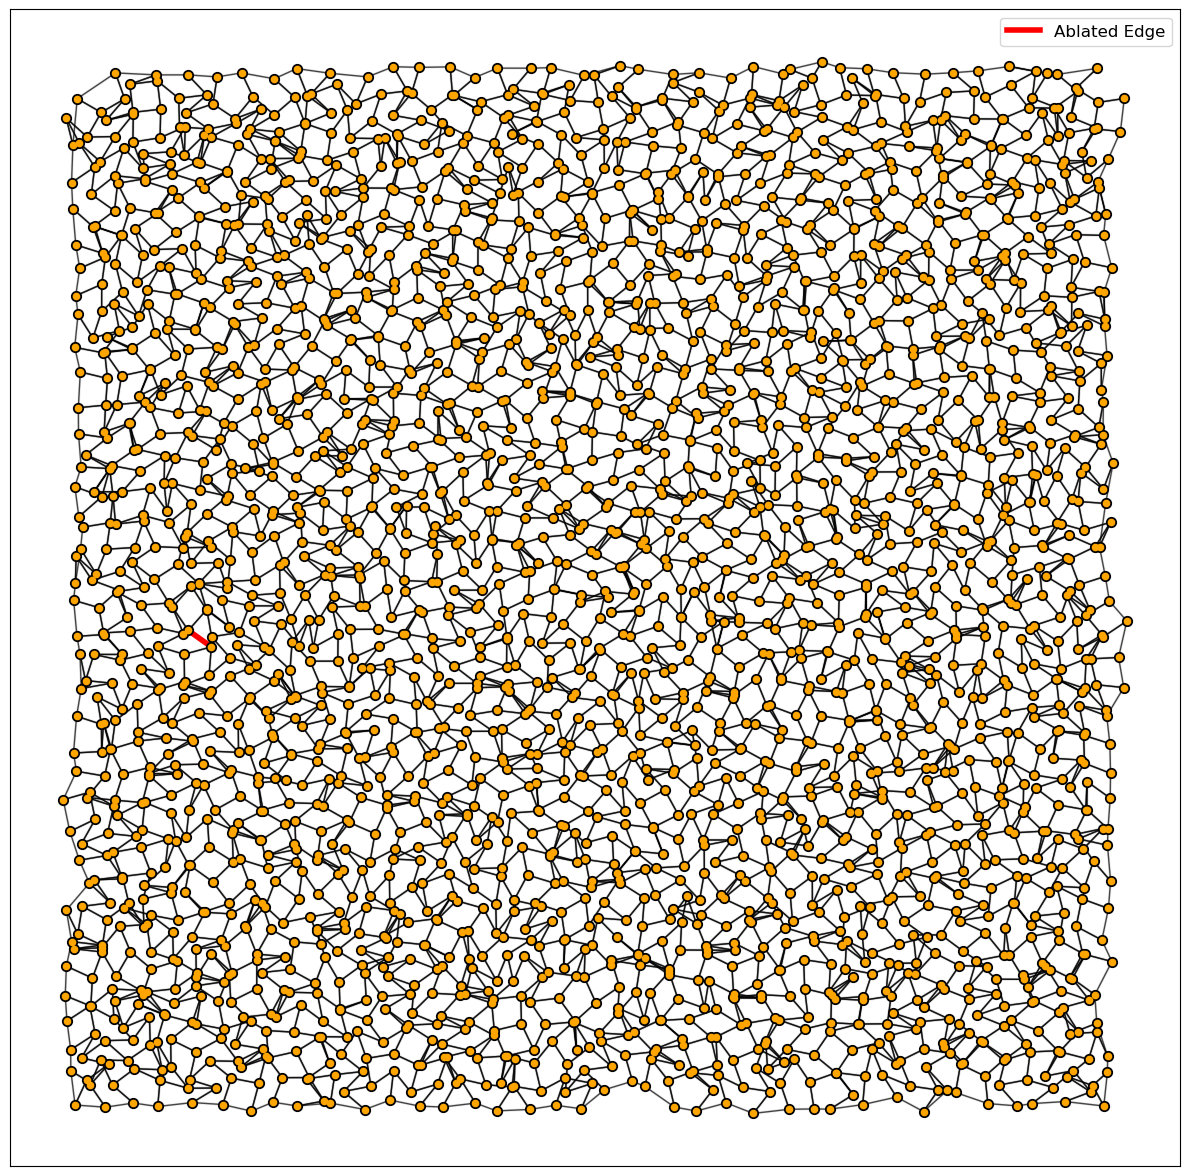

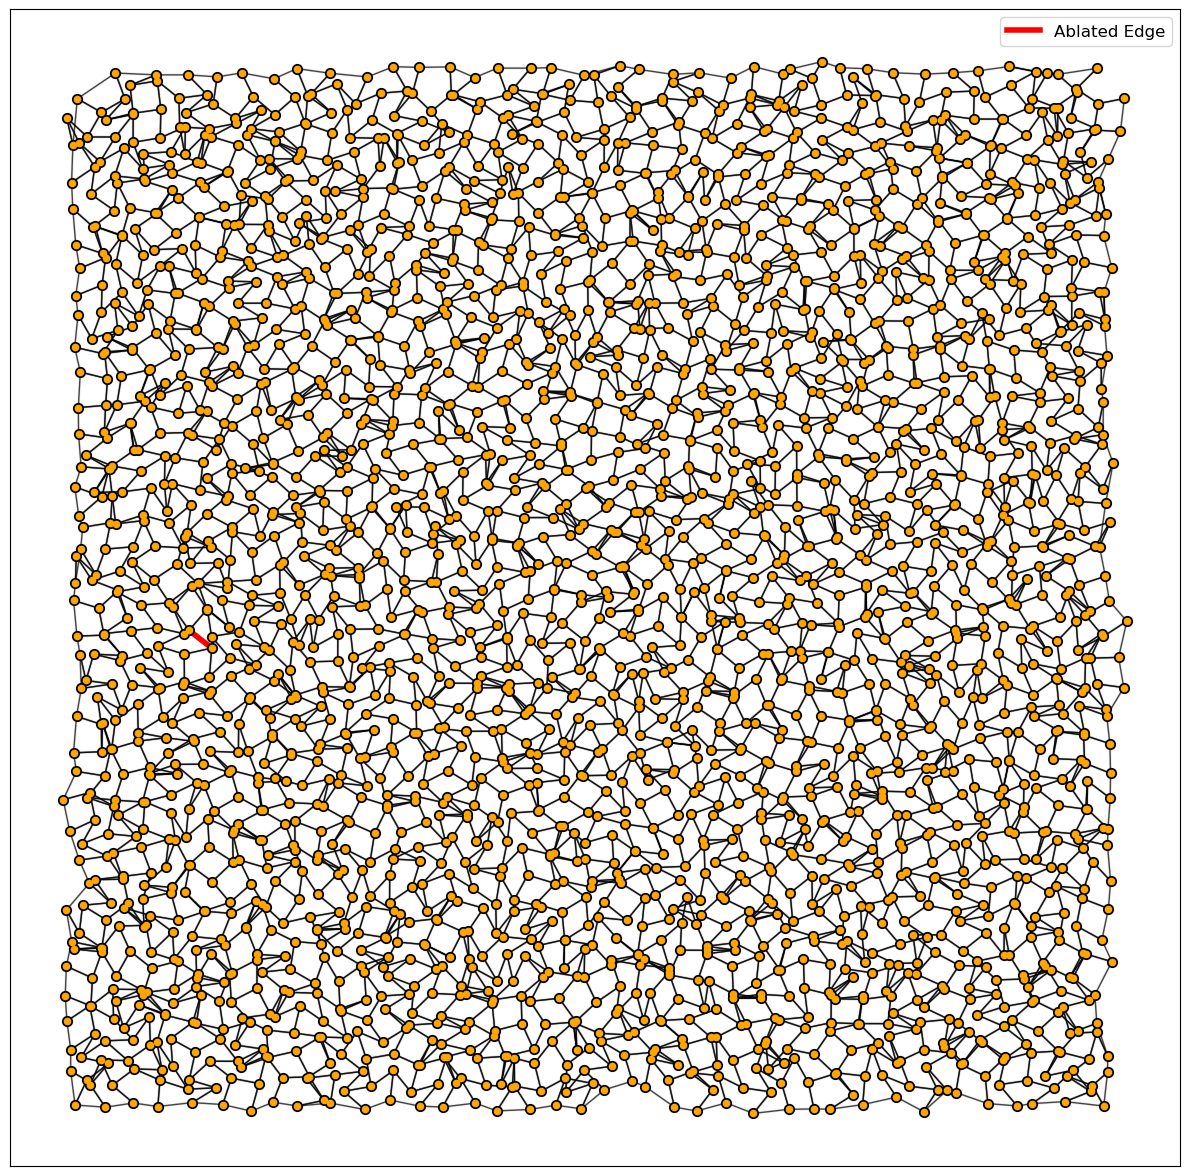

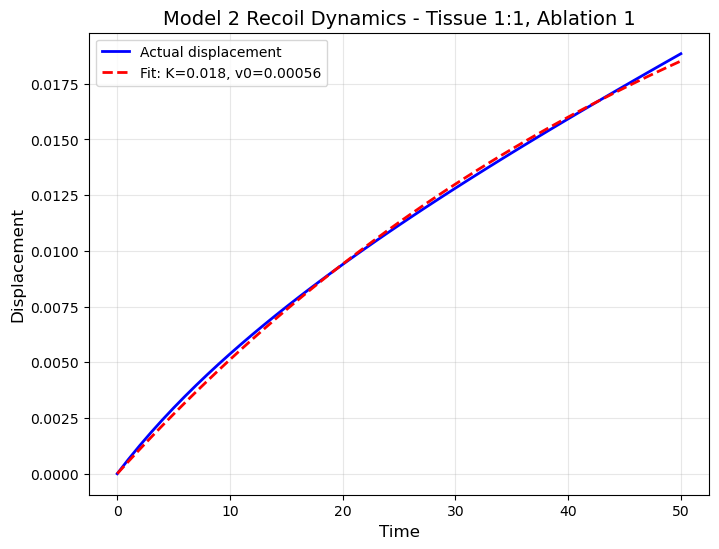

Recoil curve displayed
K = 0.018, Initial recoil = 0.00056

 Complete for ratio 1:1
   Mean K: 0.018 ± 0.000
   Mean Initial Recoil: 0.00056 ± 0.00000
   Successful ablations: 1/1
   Results saved to: Model1_collagenase_results/collagenase_ratio_1_1.json
   Plots saved to: Model1_collagenase_plots/ratio_1_1

Testing ratio 1:2 (ECM:FRC)
Collagenase: ECM will be removed after initial relaxation

--- Tissue 1/1 ---
  Initializing tissue with ECM present...
Topology changed!


KeyboardInterrupt: 

In [6]:
# RUN EXPERIMENT

# Defining ratios as (ECM, FRC) tuples to be tested
ratios = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5),  # FRC dominant
    (2, 1), (3, 1), (4, 1), (5, 1),           # ECM dominant
    (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)
]

# Running experiment 
results = run_multi_ratio_collagenase_experiment(
    ratios_ecm_frc=ratios,
    num_tissues=1,           # 3 independently initialized tissues
    ablations_per_tissue=1,  # 5 CONSECUTIVE ablations per tissue
    total_le=90,             # Total length elasticity to be split between FRC and ECM
    output_dir="Model1_collagenase_results",
    plot_dir="Model1_collagenase_plots"
)

### Model 2 collagenase laser ablations

In [ ]:
# PLOTTING SETUP

# Register the custom colormap
if 'yellow_red' not in plt.colormaps():
    custom_cmap = ListedColormap(["yellow", "red"])
    plt.register_cmap(name='yellow_red', cmap=custom_cmap)


# MODEL 2 SPECIFIC FUNCTIONS

def initialize_tissue_model2():
    """
    Initialize tissue for Model 2 (collagenase-treated, fixed boundaries).
    """
    # Initializing tissue
    cellmap, geom, energy_model = vertexModel2.initialize(40)
    cellmap = MechanicalParams2.update(cellmap)
    
    
    # Fixing outer boundary vertices with high viscosity (almost fixed)
    boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, 1)
    
    for vertex_id in outside_vertices:
        if vertex_id in cellmap.vert_df.index:
            cellmap.vert_df.at[vertex_id, "viscosity"] = 200000
                    

    cellmap.update_specs({"vert": {"viscosity": cellmap.vert_df["viscosity"].values}}, reset=True)

    # Relaxing tissue from initialisation
    energy_model.compute_energy(cellmap)
    cellmap, geom, energy_model, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energy_model, endTime=100
    )
    
    # Setting length_elasticity = 0 to simulate complete ECM degradation
    cellmap.edge_df["length_elasticity"] = 0.0
    
    # Relaxing to equilibrium
    energy_model.compute_energy(cellmap)
    cellmap, geom, energy_model, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energy_model, endTime=100
    )
    
    return cellmap, geom, energy_model


def perform_laser_ablation_model2(cellmap, geom, energy_model, endTime=50, 
                                   tissue_id=None, ablation_id=None):
    """
    Perform laser ablation on a random interior edge for Model 2.
    """
    print(f"Performing laser ablation...")
    
    # Identifying interior edges
    try:
        boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, max_layers=1)
        print(f"        Found {len(inside_edges)} interior edges")
    except Exception as e:
        print(f"        Warning: Could not identify boundary layers: {e}")
        if 'is_border' in cellmap.edge_df.columns:
            inside_edges = cellmap.edge_df[~cellmap.edge_df['is_border']].index.tolist()
        else:
            inside_edges = cellmap.edge_df.index.tolist()
        print(f"        Using fallback: found {len(inside_edges)} edges")
    
    if not inside_edges or len(inside_edges) == 0:
        raise ValueError("No inside edges found")
    
    # Choosing random edge and finding its opposite
    chosen_edge = random.choice(inside_edges)
    print(f"        Chosen edge: {chosen_edge}")
    
    if chosen_edge not in cellmap.edge_df.index:
        raise ValueError(f"Chosen edge {chosen_edge} not found in edge_df")
    
    srce = cellmap.edge_df.loc[chosen_edge, "srce"]
    trgt = cellmap.edge_df.loc[chosen_edge, "trgt"]
    
    opposite = cellmap.edge_df[
        (cellmap.edge_df["srce"] == trgt) & (cellmap.edge_df["trgt"] == srce)
    ]
    if opposite.empty:
        raise ValueError("Opposite edge not found")
    opposite_edge = opposite.index[0]
    print(f"        Opposite edge: {opposite_edge}")
    
    # Visualisation before ablation
    if tissue_id is not None and ablation_id is not None:
        print(f"Displaying tissue BEFORE ablation...")
        try:
            highlight_edge_on_cellmap(
                cellmap, 
                edge_id=chosen_edge,
                figsize=(12, 12),
                vert_col='orange',
                edge_highlight_col='red',
                show_axes=False
            )
            print(f"Before-ablation plot displayed")
        except Exception as e:
            print(f"Could not display before ablation: {e}")
    
    # Ablating the edge
    print(f"Cutting edge {chosen_edge} and opposite {opposite_edge}...")
    cellmap.edge_df.at[chosen_edge, "length_elasticity"] = 0.0
    cellmap.edge_df.at[chosen_edge, "line_tension"] = 0.0
    cellmap.edge_df.at[opposite_edge, "length_elasticity"] = 0.0
    cellmap.edge_df.at[opposite_edge, "line_tension"] = 0.0
    
    # Relaxing tissue post laser ablation
    try:
        energy_model.compute_energy(cellmap)
        cellmap, geom, energy_model, _, solver = vertexModel2.solveEuler(
            cellmap, geom, energy_model, endTime=endTime
        )
        print(f"Recoil simulation complete")
    except Exception as e:
        print(f"Error during relaxation: {e}")
        raise
    
    # Visualising after laser ablation
    if tissue_id is not None and ablation_id is not None:
        print(f"Displaying tissue AFTER ablation...")
        try:
            highlight_edge_on_cellmap(
                cellmap, 
                edge_id=chosen_edge,
                figsize=(12, 12),
                vert_col='orange',
                edge_highlight_col='red',
                show_axes=False
            )
            print(f"After-ablation plot displayed")
        except Exception as e:
            print(f"Could not display after ablation: {e}")
    
    # Tracking displacement
    print(f"Tracking vertex displacement...")
    displacement = []
    time_steps = []
    initial_distance = None
    
    for t, cm in solver.history:
        if srce not in cm.vert_df.index or trgt not in cm.vert_df.index:
            continue
            
        srce_coords = cm.vert_df.loc[srce, ['x', 'y']]
        trgt_coords = cm.vert_df.loc[trgt, ['x', 'y']]
        distance = np.linalg.norm(srce_coords - trgt_coords)
        
        if initial_distance is None:
            initial_distance = distance
        
        displacement.append(distance - initial_distance)
        time_steps.append(t)
    
    print(f"Tracked {len(time_steps)} time points")
    
    # Fitting exponential recoil model
    def recoil_model(t, initial_recoil, k):
        return (initial_recoil / k) * (1 - np.exp(-k * t))
    
    if len(time_steps) < 3:
        raise ValueError("Not enough time points for fitting")
    
    try:
        params, _ = curve_fit(recoil_model, time_steps, displacement, 
                              p0=[0.00001, 3], bounds=(0, np.inf))
        initial_recoil, k = params
        print(f"Fit successful: K={k:.3f}, initial_recoil={initial_recoil:.5f}")
    except Exception as e:
        print(f"Curve fit failed: {e}")
        initial_recoil = 0.00001
        k = 3.0
        print(f"        Using default values: K={k:.3f}, initial_recoil={initial_recoil:.5f}")
    
    # Visualising recoil curve
    if tissue_id is not None and ablation_id is not None:
        print(f"Displaying recoil curve...")
        try:
            plot_recoil_curve(
                time_steps, displacement, initial_recoil, k, 
                tissue_id, ablation_id
            )
            print(f"Recoil curve displayed")
        except Exception as e:
            print(f"Could not display recoil curve: {e}")
    
    return {
        'displacement': displacement,
        'time_steps': time_steps,
        'initial_recoil': float(initial_recoil),
        'k': float(k),
        'chosen_edge': int(chosen_edge),
        'opposite_edge': int(opposite_edge),
        'updated_cellmap': cellmap,
        'updated_geom': geom,
        'updated_energy_model': energy_model
    }


# MAIN EXPERIMENT FUNCTION

def run_model2_experiment(num_tissues=3, 
                          ablations_per_tissue=5,
                          save_path=None):
    """
    Run Model 2 experiment with consecutive ablations on the same tissue.
    """
    print(f"\n{'='*60}")
    print(f"Model 2: Collagenase-treated tissue (no ECM)")
    print(f"Fixed boundaries with high viscosity")
    print(f"{'='*60}")
    
    results = {
        'model': 'Model 2',
        'description': 'Collagenase-treated tissue (no ECM), fixed boundaries',
        'num_tissues': num_tissues,
        'ablations_per_tissue': ablations_per_tissue,
        'ablations': []
    }
    
    # Recording parameter values
    try:
        temp_cellmap, _, _ = vertexModel2.initialize()
        temp_cellmap = MechanicalParams2.update(temp_cellmap)
        results['parameters'] = {
            'area_elasticity': float(temp_cellmap.face_df['area_elasticity'].iloc[0]),
            'line_tension': float(temp_cellmap.edge_df['line_tension'].iloc[0]),
            'viscosity': float(temp_cellmap.vert_df['viscosity'].iloc[0])
        }
        print(f"\nParameters:")
        print(f"   Area Elasticity = {results['parameters']['area_elasticity']}")
        print(f"   Line Tension = {results['parameters']['line_tension']}")
        print(f"   Viscosity = {results['parameters']['viscosity']}")
    except Exception as e:
        print(f"Could not record parameters: {e}")
        results['parameters'] = {}
    
    for tissue_idx in range(num_tissues):
        print(f"\n{'─'*40}")
        print(f"Tissue {tissue_idx + 1}/{num_tissues}")
        print(f"{'─'*40}")
        
        # Initializing tissue
        print("Initializing collagenase-treated tissue with fixed boundaries...")
        cellmap, geom, energy_model = initialize_tissue_model2()
        
        # Getting initial parameter values
        frc_le_value = float(cellmap.edge_df['length_elasticity'].iloc[0]) if 'length_elasticity' in cellmap.edge_df.columns else 0
        line_tension_value = float(cellmap.edge_df['line_tension'].iloc[0])
        
        print(f"Initial conditions:")
        print(f"Length elasticity = {frc_le_value}")
        print(f"Line tension = {line_tension_value}")
        
        # Performing consecutive laser ablations
        for ablation_idx in range(ablations_per_tissue):
            ablation_num = tissue_idx * ablations_per_tissue + ablation_idx + 1
            print(f"\nAblation {ablation_idx + 1}/{ablations_per_tissue} (Total: {ablation_num})")
            print(f"  {'─'*30}")
            
            try:
                ablation_result = perform_laser_ablation_model2(
                    cellmap, geom, energy_model, endTime=100,
                    tissue_id=tissue_idx + 1,
                    ablation_id=ablation_num
                )
                
                # Updating cellmap for next ablation
                cellmap = ablation_result['updated_cellmap']
                geom = ablation_result['updated_geom']
                energy_model = ablation_result['updated_energy_model']
                
                del ablation_result['updated_cellmap']
                del ablation_result['updated_geom']
                del ablation_result['updated_energy_model']
                
                ablation_result['tissue_id'] = tissue_idx + 1
                ablation_result['ablation_id'] = ablation_num
                ablation_result['frc_le'] = frc_le_value
                ablation_result['line_tension'] = line_tension_value
                
                results['ablations'].append(ablation_result)
                
                print(f"Ablation {ablation_num} complete!")
                print(f"K = {ablation_result['k']:.3f}")
                print(f"Initial recoil = {ablation_result['initial_recoil']:.5f}")
                
            except Exception as e:
                print(f"Ablation failed: {e}")
                traceback.print_exc()
                continue
    
    # Summary statistics
    if results['ablations']:
        k_values = [a['k'] for a in results['ablations']]
        recoil_values = [a['initial_recoil'] for a in results['ablations']]
        
        results['summary'] = {
            'num_ablations': len(results['ablations']),
            'mean_k': float(np.mean(k_values)),
            'std_k': float(np.std(k_values)),
            'mean_initial_recoil': float(np.mean(recoil_values)),
            'std_initial_recoil': float(np.std(recoil_values))
        }
    else:
        results['summary'] = {
            'num_ablations': 0,
            'mean_k': None,
            'std_k': None,
            'mean_initial_recoil': None,
            'std_initial_recoil': None
        }
    
    print(f"\n{'='*60}")
    print(f"Model 2 Complete!")
    print(f"{'='*60}")
    print(f"Summary Statistics:")
    print(f"   Successful ablations: {len(results['ablations'])}/{num_tissues * ablations_per_tissue}")
    if results['summary']['mean_k']:
        print(f"   Mean K: {results['summary']['mean_k']:.3f} ± {results['summary']['std_k']:.3f}")
        print(f"   Mean Initial Recoil: {results['summary']['mean_initial_recoil']:.5f} ± {results['summary']['std_initial_recoil']:.5f}")
    
    # Saving results (JSON only, no plots saved)
    if save_path:
        with open(save_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"\nResults saved to: {save_path}")
    
    print(f"{'='*60}")
    
    return results


In [ ]:
# RUN EXPERIMENT
 
results = run_model2_experiment(
    num_tissues=3,           # 3 independently initialized tissues
    ablations_per_tissue=5,  # 5 consecutive ablations per tissue
    save_path="Model2_results.json"  # Only saves JSON data, not plots
    )